## pip install mne mne-icalabel scipy

In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis
from mne_icalabel import label_components

/opt/homebrew/Cellar/jupyterlab/4.5.6/libexec/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
raw_A = mne.io.read_raw_edf('Listener.edf', preload=True)
raw_B = mne.io.read_raw_edf('Speaker.edf', preload=True)

print(raw_A.ch_names)

Extracting EDF parameters from Listener.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 75749  =      0.000 ...   302.996 secs...
Extracting EDF parameters from Speaker.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 75749  =      0.000 ...   302.996 secs...
['EEG 1', 'EEG 2', 'EEG 3', 'EEG 4', 'EEG 5', 'EEG 6', 'EEG 7', 'EEG 8', 'EEG 9', 'EEG 10', 'EEG 11', 'EEG 12', 'EEG 13', 'EEG 14', 'EEG 15', 'EEG 16', 'EEG 17', 'EEG 18', 'EEG 19', 'EEG 20', 'EEG 21', 'EEG 22', 'EEG 23', 'EEG 24', 'EEG 25', 'EEG 26', 'EEG 27', 'EEG 28', 'EEG 29', 'EEG 30', 'EEG 31', 'EEG 32', 'EEG 33', 'EEG 34', 'EEG 35', 'EEG 36', 'EEG 37', 'EEG 38', 'EEG 39', 'EEG 40', 'EEG 41', 'EEG 42', 'EEG 43', 'EEG 44', 'EEG 45', 'EEG 46', 'EEG 47', 'EEG 48', 'EEG 49', 'EEG 50', 'EEG 51', 'EEG 52', 'EEG 53', 'EEG 54', 'EEG 55', 'EEG 56', 'EEG 57', 'EEG 58', 'EEG 59', 'EEG 60', 'EEG 61', 'EEG 62', 'EEG 63', 'EEG 64', 'EEG VREF']


In [4]:
events_A, event_id_A = mne.events_from_annotations(raw_A)
events_B, event_id_B = mne.events_from_annotations(raw_B)

print(event_id_A)  # find DIN1 code

Used Annotations descriptions: [np.str_('DIN1')]
Used Annotations descriptions: [np.str_('DIN1'), np.str_('VBeg'), np.str_('VEnd')]
{np.str_('DIN1'): 1}


In [5]:
din_key = [k for k in event_id_A.keys() if 'DIN1' in k][0]
din_id = event_id_A[din_key]

din_events_A = events_A[events_A[:, 2] == din_id]
din_events_B = events_B[events_B[:, 2] == din_id]

sfreq = raw_A.info['sfreq']

times_A = din_events_A[:, 0] / sfreq
times_B = din_events_B[:, 0] / sfreq

pos_A = raw_A.copy().crop(tmin=times_A[0], tmax=times_A[1])
pos_B = raw_B.copy().crop(tmin=times_B[0], tmax=times_B[1])

neg_A = raw_A.copy().crop(tmin=times_A[2], tmax=None)
neg_B = raw_B.copy().crop(tmin=times_B[2], tmax=None)

In [6]:
for raw in [pos_A, pos_B, neg_A, neg_B]:
    raw.drop_channels(['EEG VREF'])  # exact name from your data

In [7]:
def preprocess(raw):
    raw.filter(1., 40.)                      # band-pass
    raw.set_eeg_reference('average')         # average reference
    return raw

pos_A = preprocess(pos_A)
pos_B = preprocess(pos_B)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passb

In [8]:
ica = mne.preprocessing.ICA(n_components=0.95, random_state=42)
ica.fit(pos_A)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by explained variance: 16 components
Fitting ICA took 0.6s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,55 iterations on raw data (36944 samples)
ICA components,16
Available PCA components,64
Channel types,eeg
ICA components marked for exclusion,—


In [9]:
sources = ica.get_sources(pos_A).get_data()


In [10]:
# Apply same ICA to pos_B
ica_B = mne.preprocessing.ICA(n_components=0.95, random_state=42)
ica_B.fit(pos_B)
sources_B = ica_B.get_sources(pos_B).get_data()
var_B = np.var(sources_B, axis=1)
kurt_B = kurtosis(sources_B, axis=1)
bad_idx_B = [i for i in range(len(var_B)) if kurt_B[i] > 10]
ica_B.exclude = bad_idx_B
clean_B = ica_B.apply(pos_B.copy())

# Also preprocess neg segments
neg_A = preprocess(neg_A)
neg_B = preprocess(neg_B)

ica_negA = mne.preprocessing.ICA(n_components=0.95, random_state=42)
ica_negA.fit(neg_A)
sources_negA = ica_negA.get_sources(neg_A).get_data()
kurt_negA = kurtosis(sources_negA, axis=1)
bad_idx_negA = [i for i in range(len(kurt_negA)) if kurt_negA[i] > 10]
ica_negA.exclude = bad_idx_negA
clean_negA = ica_negA.apply(neg_A.copy())

ica_negB = mne.preprocessing.ICA(n_components=0.95, random_state=42)
ica_negB.fit(neg_B)
sources_negB = ica_negB.get_sources(neg_B).get_data()
kurt_negB = kurtosis(sources_negB, axis=1)
bad_idx_negB = [i for i in range(len(kurt_negB)) if kurt_negB[i] > 10]
ica_negB.exclude = bad_idx_negB
clean_negB = ica_negB.apply(neg_B.copy())

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by explained variance: 16 components
Fitting ICA took 0.2s.
Applying ICA to Raw instance
    Transforming to ICA space (16 components)
    Zeroing out 10 ICA components
    Projecting back using 64 PCA components
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 

In [11]:
import numpy as np
from scipy.stats import kurtosis

var = np.var(sources, axis=1)
kurt = kurtosis(sources, axis=1)

In [12]:
threshold_var = np.percentile(var, 90)

bad_idx = [i for i in range(len(var)) if kurt[i] > 35]

print("Rejected components:", bad_idx)

Rejected components: [2, 3, 5, 8, 9]


In [13]:
ica.exclude = bad_idx
clean_A = ica.apply(pos_A.copy())

Applying ICA to Raw instance
    Transforming to ICA space (16 components)
    Zeroing out 5 ICA components
    Projecting back using 64 PCA components


Effective window size : 1.024 (s)
Effective window size : 1.024 (s)


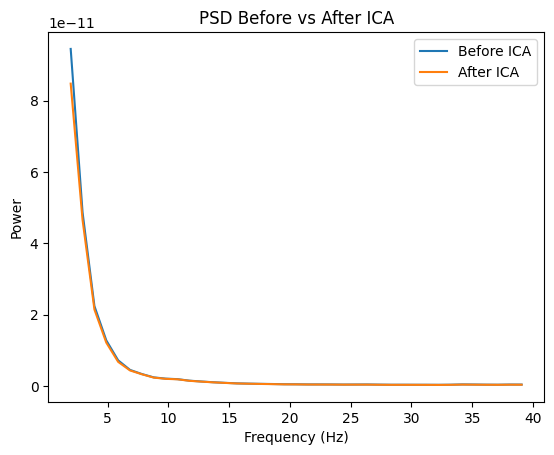

In [14]:
psd_before, freqs = mne.time_frequency.psd_array_welch(
    pos_A.get_data(), sfreq=pos_A.info['sfreq'], fmin=1, fmax=40)

psd_after, _ = mne.time_frequency.psd_array_welch(
    clean_A.get_data(), sfreq=clean_A.info['sfreq'], fmin=1, fmax=40)

psd_before_mean = psd_before.mean(axis=0)
psd_after_mean = psd_after.mean(axis=0)

import matplotlib.pyplot as plt

plt.plot(freqs, psd_before_mean, label='Before ICA')
plt.plot(freqs, psd_after_mean, label='After ICA')
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('PSD Before vs After ICA')
plt.show()

In [15]:
import numpy as np

# Get raw data arrays, shape = (64 channels, time samples)
# .T flips it to (time samples, 64 channels) — that's what we need
pos_A_data = pos_A.get_data().T
pos_B_data = pos_B.get_data().T
neg_A_data = neg_A.get_data().T
neg_B_data = neg_B.get_data().T

print(pos_A_data.shape)  # should be (timepoints, 64)

(36944, 64)


In [16]:
# Match positive segment lengths
min_pos = min(len(pos_A_data), len(pos_B_data))
pos_A_data = pos_A_data[:min_pos]
pos_B_data = pos_B_data[:min_pos]

# Match negative segment lengths
min_neg = min(len(neg_A_data), len(neg_B_data))
neg_A_data = neg_A_data[:min_neg]
neg_B_data = neg_B_data[:min_neg]

In [17]:
# Stack positive segments side by side: (time, 128)
pos_combined = np.concatenate([pos_A_data, pos_B_data], axis=1)

# Stack negative segments side by side: (time, 128)
neg_combined = np.concatenate([neg_A_data, neg_B_data], axis=1)

# Stack positive and negative on top of each other
X = np.concatenate([pos_combined, neg_combined], axis=0)

print(X.shape)  # should be (total_timepoints, 128)

(75431, 128)


In [18]:
# Z-normalize each channel independently
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [19]:
# Label positive timepoints as 0, negative as 1
labels_pos = np.zeros(len(pos_combined), dtype=int)   # all zeros
labels_neg = np.ones(len(neg_combined), dtype=int)    # all ones

# Stack them to match X
y = np.concatenate([labels_pos, labels_neg], axis=0)

print(X.shape, y.shape)  # these must have same number of rows

(75431, 128) (75431,)


In [20]:
import sys
!{sys.executable} -m pip install torch --no-deps
!{sys.executable} -m pip install cebra --no-deps
!{sys.executable} -m pip install filelock networkx fsspec literate-dataclasses

In [21]:
import cebra

# Create the model
model = cebra.CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=3,      # they asked for 3D embeddings
    max_iterations=1000,
    distance='cosine',
    conditional='time_delta',
    device='cpu',
    verbose=True
)

# Fit it
model.fit(X, y)

# Get the embeddings
embedding = model.transform(X)

print(embedding.shape)  # should be (total_timepoints, 3)

pos: -0.9690 neg:  7.2058 total:  6.2368 temperature:  1.0000: 100%|████████████████| 1000/1000 [05:02<00:00,  3.31it/s]

(75431, 3)


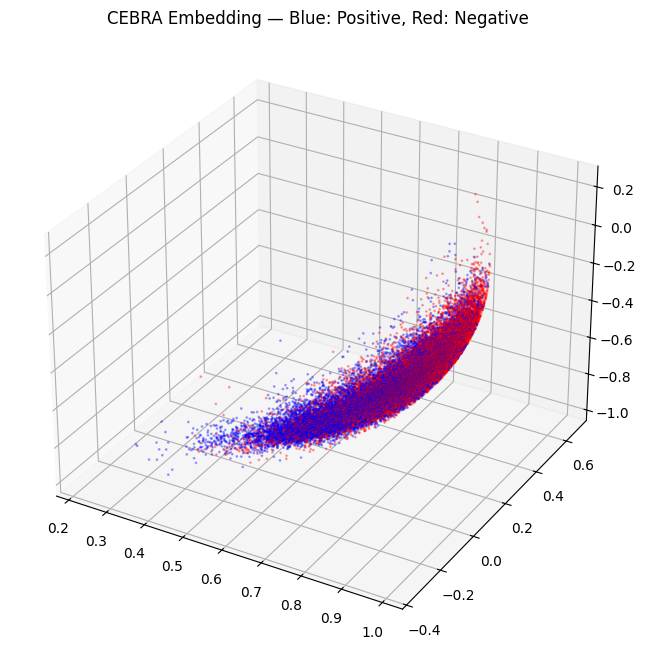

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Color by label — blue for positive, red for negative
colors = ['blue' if label == 0 else 'red' for label in y]

ax.scatter(
    embedding[:, 0],
    embedding[:, 1], 
    embedding[:, 2],
    c=colors,
    alpha=0.3,
    s=1
)

ax.set_title('CEBRA Embedding — Blue: Positive, Red: Negative')
plt.savefig('embedding.png', dpi=150)
plt.show()

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

knn = KNeighborsClassifier(n_neighbors=5)
scores = cross_val_score(knn, embedding, y, cv=5)

print(f"KNN Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

KNN Accuracy: 0.537 ± 0.013


In [24]:
# Goodness of fit via R2 score on embeddings
from sklearn.metrics import r2_score
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(embedding, y)
y_pred = knn_reg.predict(embedding)
gof = r2_score(y, y_pred)
print(f"Goodness of fit (R²): {gof:.4f}")

Goodness of fit (R²): 0.2544


In [25]:
# Shuffle labels randomly
y_shuffled = y.copy()
np.random.shuffle(y_shuffled)

# Run CEBRA again on shuffled labels
model_shuffled = cebra.CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=3,
    max_iterations=1000,
    distance='cosine',
    conditional='time_delta',
    device='cpu',
    verbose=True
)

model_shuffled.fit(X, y_shuffled)
embedding_shuffled = model_shuffled.transform(X)

# KNN on shuffled
scores_shuffled = cross_val_score(knn, embedding_shuffled, y_shuffled, cv=5)

# Goodness of fit for shuffled
knn_reg_shuffled = KNeighborsRegressor(n_neighbors=5)
knn_reg_shuffled.fit(embedding_shuffled, y_shuffled)
y_pred_shuffled = knn_reg_shuffled.predict(embedding_shuffled)
gof_shuffled = r2_score(y_shuffled, y_pred_shuffled)

print(f"Shuffled KNN Accuracy: {scores_shuffled.mean():.3f}")
print(f"Shuffled Goodness of fit (R²): {gof_shuffled:.4f}")

pos: -0.9833 neg:  7.2213 total:  6.2380 temperature:  1.0000: 100%|████████████████| 1000/1000 [05:48<00:00,  2.87it/s]


Shuffled KNN Accuracy: 0.502
Shuffled Goodness of fit (R²): 0.2008
